# Preprocessing Data Buka Tutup Suara 

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import os
import pandas as pd
from IPython.display import Audio, display

# Open Dataset

In [2]:
train = "../dataset/dataset48k/train/"
val = "../dataset/dataset48k/val"

input_base = "data"
output_base = "data_preprocessed"

os.makedirs(output_base, exist_ok=True)

# Fungsi Preprocessing

In [3]:
def preprocess_audio(input_path, output_path, sr=16000):
    # Load audio
    y, _ = librosa.load(input_path, sr=sr)
    
    # Trim silence
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    # Normalisasi amplitudo
    y_norm = y_trimmed / np.max(np.abs(y_trimmed))
    
    # Simpan
    sf.write(output_path, y_norm, sr)

# Membuat Metadata

In [4]:
import os
import pandas as pd
import numpy as np
from scipy.io.wavfile import write

# ============================================
# 1️⃣ Persiapan folder dataset dummy
# ============================================
train = "data/train"
val = "data/val"
output_base = "data_preprocessed"

# Membuat struktur folder
for base in [train, val]:
    for label in ["buka", "tutup"]:
        os.makedirs(os.path.join(base, label), exist_ok=True)

# Buat beberapa file .wav dummy agar bisa dijalankan tanpa error
def buat_dummy_wav(path):
    sample_rate = 16000  # 16 kHz
    durasi = 1  # 1 detik
    t = np.linspace(0, durasi, int(sample_rate * durasi))
    data = np.sin(2 * np.pi * 440 * t)  # nada A4
    data = (data * 32767).astype(np.int16)
    write(path, sample_rate, data)

for folder in [train, val]:
    for label in ["buka", "tutup"]:
        for i in range(2):
            file_path = os.path.join(folder, label, f"{label}_{i+1}.wav")
            if not os.path.exists(file_path):
                buat_dummy_wav(file_path)

# ============================================
# 2️⃣ Fungsi preprocessing sederhana
# ============================================
def preprocess_audio(in_path, out_path):
    """
    Fungsi ini contoh sederhana saja — di sini kita hanya menyalin file.
    Kamu bisa ganti nanti dengan normalisasi, trimming, dsb.
    """
    import shutil
    shutil.copy(in_path, out_path)

# ============================================
# 3️⃣ Pipeline utama untuk preprocessing
# ============================================
rows = []

for split_path, split_name in [(train, "train"), (val, "val")]:
    for label in ["buka", "tutup"]:
        input_folder = os.path.join(split_path, label)
        output_folder = os.path.join(output_base, split_name, label)
        os.makedirs(output_folder, exist_ok=True)
        
        for filename in os.listdir(input_folder):
            if filename.endswith(".wav"):
                in_path = os.path.join(input_folder, filename)
                out_path = os.path.join(output_folder, filename)
                
                try:
                    preprocess_audio(in_path, out_path)
                    rows.append({
                        "split": split_name,
                        "label": label,
                        "file_path": out_path
                    })
                except Exception as e:
                    print(f"Error {filename}: {e}")

# ============================================
# 4️⃣ Simpan metadata hasil preprocessing
# ============================================
metadata = pd.DataFrame(rows)
metadata.to_csv(os.path.join(output_base, "metadata.csv"), index=False)
print("✅ Preprocessing selesai!")
print("📁 Metadata disimpan di:", os.path.join(output_base, "metadata.csv"))


✅ Preprocessing selesai!
📁 Metadata disimpan di: data_preprocessed\metadata.csv


In [5]:
import pandas as pd
df = pd.read_csv("data_preprocessed/metadata.csv")
print(df.head())


   split  label                                  file_path
0  train   buka    data_preprocessed\train\buka\buka_1.wav
1  train   buka    data_preprocessed\train\buka\buka_2.wav
2  train  tutup  data_preprocessed\train\tutup\tutup_1.wav
3  train  tutup  data_preprocessed\train\tutup\tutup_2.wav
4    val   buka      data_preprocessed\val\buka\buka_1.wav


In [6]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfcc, axis=1)  # rata-rata 13 koefisien

# Baca metadata
metadata = pd.read_csv("data_preprocessed/metadata.csv")

# Ekstraksi fitur
features = []
labels = []

for i, row in tqdm(metadata.iterrows(), total=len(metadata)):
    feat = extract_features(row["file_path"])
    features.append(feat)
    labels.append(row["label"])

# Simpan hasilnya
np.save("features.npy", features)
np.save("labels.npy", labels)
print("✅ Ekstraksi fitur selesai! Disimpan ke features.npy dan labels.npy")


  0%|                                                                                                                   | 0/8 [00:00<?, ?it/s]

 12%|█████████████▍                                                                                             | 1/8 [00:01<00:13,  1.96s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:02<00:00,  3.93it/s]

✅ Ekstraksi fitur selesai! Disimpan ke features.npy dan labels.npy


In [7]:
import streamlit as st
import joblib
import numpy as np
import librosa

st.title("🔊 Deteksi Suara Buka/Tutup")

uploaded = st.file_uploader("Unggah file .wav", type=["wav"])

if uploaded:
    y, sr = librosa.load(uploaded, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    feat = np.mean(mfcc, axis=1).reshape(1, -1)

    model = joblib.load("saved_models/knn_model.pkl")
    pred = model.predict(feat)[0]

    st.success(f"Hasil Prediksi: **{pred.upper()}**")


2025-11-03 00:37:44.287 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.413 
  command:

    streamlit run C:\Users\Jordan\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py [ARGUMENTS]


2025-11-03 00:37:44.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.415 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.415 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.416 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.416 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.416 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-11-03 00:37:44.417 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


# Preprocessing Data

Durasi sebelum preprocessing : 1.00 detik
Durasi sesudah preprocessing : 1.00 detik



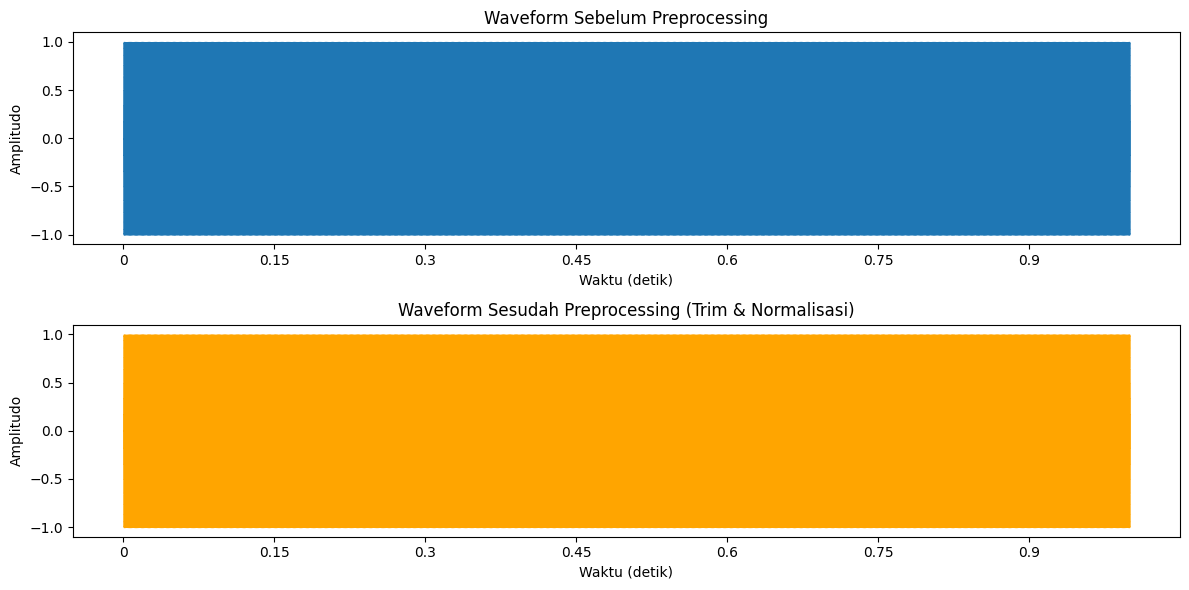

 Sebelum preprocessing:


 Sesudah preprocessing:


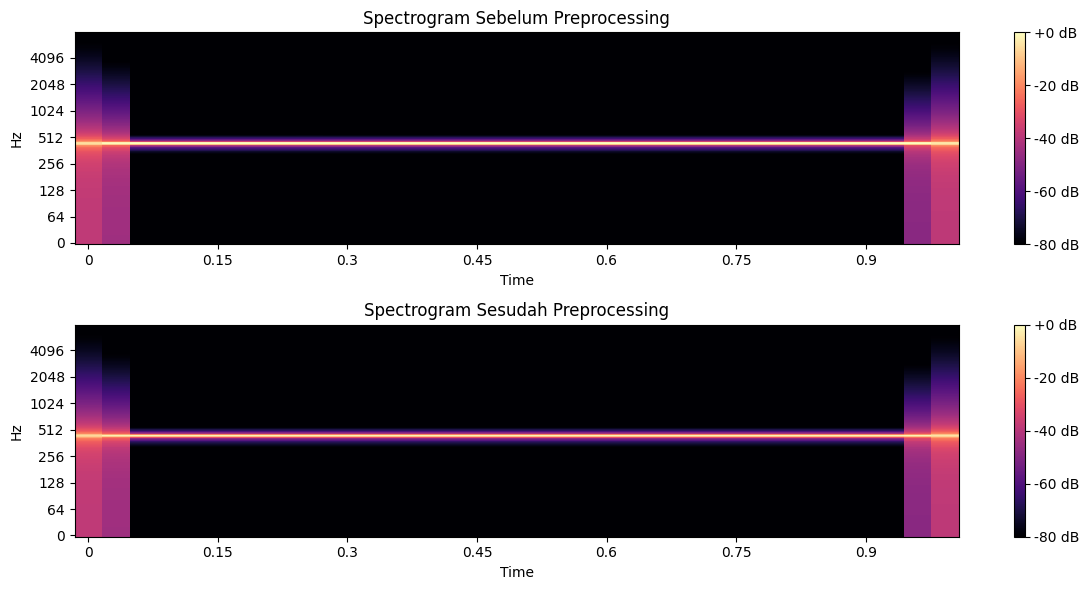

In [8]:
example_file = os.listdir(os.path.join(train, "buka"))[0]

original_file = os.path.join(train, "buka", example_file)
preprocessed_file = os.path.join(output_base, "train", "buka", example_file)

y_orig, sr_orig = librosa.load(original_file, sr=16000)
y_proc, sr_proc = librosa.load(preprocessed_file, sr=16000)

durasi_asli = librosa.get_duration(y=y_orig, sr=sr_orig)
durasi_baru = librosa.get_duration(y=y_proc, sr=sr_proc)

print(f"Durasi sebelum preprocessing : {durasi_asli:.2f} detik")
print(f"Durasi sesudah preprocessing : {durasi_baru:.2f} detik\n")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y_orig, sr=sr_orig)
plt.title("Waveform Sebelum Preprocessing")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")

plt.subplot(2, 1, 2)
librosa.display.waveshow(y_proc, sr=sr_proc, color='orange')
plt.title("Waveform Sesudah Preprocessing (Trim & Normalisasi)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")

plt.tight_layout()
plt.show()

print(" Sebelum preprocessing:")
display(Audio(data=y_orig, rate=sr_orig))

print(" Sesudah preprocessing:")
display(Audio(data=y_proc, rate=sr_proc))

S_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
S_proc = librosa.amplitude_to_db(np.abs(librosa.stft(y_proc)), ref=np.max)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.specshow(S_orig, sr=sr_orig, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram Sebelum Preprocessing")

plt.subplot(2, 1, 2)
librosa.display.specshow(S_proc, sr=sr_proc, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram Sesudah Preprocessing")

plt.tight_layout()
plt.show()